# GNN variation test

This notebook calls `sequence_to_svm_minimal/scripts/run_gnn_train_final_models.py` five times with the **same** JSON preset (`configs/gnn_final_train.json` by default), the **same** hyperparameters, and the **same** `--seed` every time. Only `--run-name` changes so each subprocess writes one repeat folder. Any spread in validation metrics is from nondeterministic execution (for example GPU ops), not from different splits or seeds.

**Output layout:** Each notebook experiment uses one subfolder under ``results/gnn/gnn_variation_test`` (default name ``exp_YYYYMMDD_HHMMSS``); the five repeats are ``repeat_*`` **inside** that folder.

**Environment:** The subprocess uses the same interpreter as this notebook (`sys.executable`). You need **PyTorch** and **PyTorch Geometric** in that environment. If imports work but training still exits immediately, the next common cause is **per-residue ESM2**: `gnn_final_train.json` sets `node_feature_groups.esm2_residue` to true, so the script expects a folder `esm2_per_residue/` next to your ESM2 CSVs (one `.pt` per peptide), as produced by the data pipeline. Either run the pipeline and set `GENERATED` to that workspace, populate `esm2_per_residue` beside `esm2_embeddings.csv`, or set `NODE_GROUPS_CLI = "no_esm2"` in the knobs cell to train without on-node ESM2 (different graph features than the default config).

**Note:** Use `--models ARCH:FEATURE` (below) to pin a **single** backbone and tabular mode while everything else stays on the config defaults.

**Reloading results:** Set ``LOAD_EXISTING_ONLY = True`` in the knobs cell. ``RESULTS_FROM`` may be a directory that contains ``repeat_*`` directly, **or** any immediate subfolder that holds repeats (for example ``exp_first/repeat_*``), **or** the latest ``exp_*`` timestamped experiment under that directory. You can also point ``RESULTS_FROM`` at a specific folder that contains the repeats, or at a saved ``.csv`` / ``.parquet`` of the metrics ``df``. When loading from ``ready_models_summary.json``, checkpoint paths are re-resolved beside each summary if the stored path moved with the repeat folder.

In [10]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import importlib.util

import pandas as pd


def _require_gnn_training_stack() -> None:
    if importlib.util.find_spec("torch") is None:
        raise ImportError("Install PyTorch in this notebook's environment (import torch).")
    if importlib.util.find_spec("torch_geometric") is None:
        raise ImportError(
            "Missing torch_geometric. The training script imports it on startup. "
            "Install in this same env (e.g. pip install torch-geometric, or "
            "pip install -r sequence_to_svm_minimal/requirements.txt). "
            "See https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html"
        )


def find_sequence_to_svm_minimal() -> Path:
    start = Path.cwd().resolve()
    marker = Path("scripts") / "run_gnn_train_final_models.py"
    if (start / marker).is_file():
        return start
    for base in start.parents:
        cand = base / "sequence_to_svm_minimal" / marker
        if cand.is_file():
            return base / "sequence_to_svm_minimal"
    raise FileNotFoundError(
        "Could not locate sequence_to_svm_minimal/scripts/run_gnn_train_final_models.py "
        "from the current working directory. cd to sequence_to_svm_minimal or repo root."
    )


MINIMAL = find_sequence_to_svm_minimal()
_require_gnn_training_stack()
print("sequence_to_svm_minimal:", MINIMAL)
print("Interpreter:", sys.executable)

sequence_to_svm_minimal: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal
Interpreter: c:\Users\bioin\miniconda3\envs\gnn_notebooks\python.exe


In [11]:
# --- User knobs ---
from datetime import datetime

CONFIG_REL = Path("configs/gnn_final_train.json")
N_RUNS = 5

# Pin one model: list of "ARCH:FEATURE" strings. Set to None to train the full grid from the JSON
# (e.g. all architectures × each post-MP tabular preset from config) on every repeat.
MODELS: list[str] | None = ["gat:ESM"]

# Optional: path to pipeline generated/ (or parent). None = rely on csv_path / pdb_dir in JSON only.
GENERATED: str | None = None

# Parent directory for all variation experiments (relative to sequence_to_svm_minimal: results/gnn/gnn_variation_test).
OUTPUT_BASE = MINIMAL / "results" / "gnn" / "gnn_variation_test" / "exp_first"

# Each notebook "experiment" is one subfolder here; repeats live inside it (not as five siblings under OUTPUT_BASE).
EXPERIMENT_ID: str | None = None  # e.g. "exp_manual"; None → exp_YYYYMMDD_HHMMSS when this cell runs
OUTPUT_RUN_ROOT = OUTPUT_BASE / (EXPERIMENT_ID or datetime.now().strftime("exp_%Y%m%d_%H%M%S"))

# The training script refuses an existing --run-name dir (mkdir(exist_ok=False)). When True, remove
# OUTPUT_RUN_ROOT/<run_name> before each subprocess so you can re-run this notebook. Set False to keep old runs.
DELETE_EXISTING_RUN_DIRS = True

# Single seed for every repeat (config file seed unless overridden).
USE_CONFIG_SEED = True
SEED_OVERRIDE: int | None = None  # e.g. 123 to ignore the JSON seed

# Optional: override node blocks (comma-separated tokens). Use "no_esm2" if you have no
# esm2_per_residue/ directory next to the ESM2 CSVs (trains a different graph layout than the JSON default).
NODE_GROUPS_CLI: str | None = None  # e.g. "no_esm2"

# When True, skip subprocess training and load metrics from RESULTS_FROM (see optional cell).
LOAD_EXISTING_ONLY = True

# Default: same tree as OUTPUT_BASE. When loading, uses latest exp_* experiment under this dir unless you
# point RESULTS_FROM at a specific exp_ folder or at a saved .csv / .tsv / .parquet of ``df``.
RESULTS_FROM: str | Path | None = OUTPUT_BASE

# When True, repeat summary stats and validation bar charts use val_loss only (no AUC/accuracy bars).
VARIATION_FOCUS_LOSS_ONLY = True

print("OUTPUT_BASE:", OUTPUT_BASE)
print("OUTPUT_RUN_ROOT (this experiment):", OUTPUT_RUN_ROOT)

PYTHON = sys.executable
SCRIPT = MINIMAL / "scripts" / "run_gnn_train_final_models.py"

OUTPUT_BASE: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\results\gnn\gnn_variation_test\exp_first
OUTPUT_RUN_ROOT (this experiment): C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\results\gnn\gnn_variation_test\exp_first\exp_20260513_154035


In [12]:
# Optional overrides (run after the knobs cell):
# LOAD_EXISTING_ONLY = True   # skip training; load from RESULTS_FROM
# RESULTS_FROM = OUTPUT_BASE / "exp_20260213_153000"  # one experiment folder
# RESULTS_FROM = OUTPUT_BASE / "gnn_variation_metrics.parquet"  # saved df: df.to_parquet(...)

pass

In [13]:
cfg_path = MINIMAL / CONFIG_REL
with open(cfg_path, encoding="utf-8") as f:
    cfg_json = json.load(f)
if SEED_OVERRIDE is not None:
    fixed_seed = int(SEED_OVERRIDE)
elif USE_CONFIG_SEED:
    fixed_seed = int(cfg_json.get("seed", 42))
else:
    fixed_seed = 42
seeds = [fixed_seed] * N_RUNS
print("Seed (all runs):", fixed_seed)

_ng = (NODE_GROUPS_CLI or "").lower()
_wants_esm2_nodes = (cfg_json.get("node_feature_groups") or {}).get("esm2_residue", False) and "no_esm2" not in _ng
if _wants_esm2_nodes:
    anchor_rel = (
        cfg_json.get("esm2_csv")
        or cfg_json.get("qsar_csv")
    )
    if not anchor_rel:
        raise ValueError("Config enables esm2_residue but no ESM2/QSAR path in JSON to infer esm2_per_residue/.")
    esm2_res_dir = (MINIMAL / anchor_rel).resolve().parent / "esm2_per_residue"
    if not esm2_res_dir.is_dir():
        raise FileNotFoundError(
            f"Per-residue ESM2 folder missing (config has esm2_residue: true):\n  {esm2_res_dir}\n"
            "Populate it (pipeline ESM2 step), point GENERATED at pipeline generated/, or set "
            'NODE_GROUPS_CLI = "no_esm2" in the knobs cell.'
        )
    print("Per-residue ESM2 dir OK:", esm2_res_dir)

Seed (all runs): 42
Per-residue ESM2 dir OK: C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\data\gnn_training_dataset\normalized_combined_set\generated\esm2_per_residue


In [14]:
import os
import shutil

summaries: list[Path] = []
_loaded_metrics_table = None

if LOAD_EXISTING_ONLY and RESULTS_FROM is not None:
    _src = Path(RESULTS_FROM).expanduser().resolve()
    _suf = _src.suffix.lower()
    if _suf in (".csv", ".tsv", ".parquet", ".pq"):
        if not _src.is_file():
            raise FileNotFoundError(_src)
        _loaded_metrics_table = _src
        print(f"Skip training: will load metrics table from {_src}")
    elif _src.is_dir():

        def _summaries_from_results_root(root: Path) -> list[Path]:
            flat = sorted(root.glob("repeat_*/ready_models_summary.json"))
            if flat:
                return flat
            nested = list(root.glob("*/repeat_*/ready_models_summary.json"))
            if nested:
                by_bundle: dict[Path, list[Path]] = {}
                for p in nested:
                    by_bundle.setdefault(p.parent.parent, []).append(p)
                best = max(
                    by_bundle.values(),
                    key=lambda paths: max(x.stat().st_mtime for x in paths),
                )
                return sorted(best)
            exp_dirs = [p for p in root.iterdir() if p.is_dir() and p.name.startswith("exp_")]
            if not exp_dirs:
                return []
            exp_dirs.sort(key=lambda p: p.stat().st_mtime, reverse=True)
            for ed in exp_dirs:
                hit = sorted(ed.glob("repeat_*/ready_models_summary.json"))
                if hit:
                    return hit
            return []

        summaries = _summaries_from_results_root(_src)
        if not summaries:
            raise FileNotFoundError(
                f"No ready_models_summary.json under {_src} (expected repeat_* here, under any subfolder "
                "like exp_first/repeat_*, or under exp_*). Set RESULTS_FROM to that folder or a saved .csv/.parquet."
            )
        print(f"Skip training: loaded {len(summaries)} summary file(s) from {_src}")
    else:
        raise ValueError(
            f"RESULTS_FROM must be a directory or .csv/.tsv/.parquet; got {_src}"
        )
else:

    OUTPUT_RUN_ROOT.mkdir(parents=True, exist_ok=True)
    print("Experiment output:", OUTPUT_RUN_ROOT, flush=True)

    def run_final_gnn_train(*, seed: int, run_name: str) -> Path:
        out_run = OUTPUT_RUN_ROOT / run_name
        if out_run.exists():
            if DELETE_EXISTING_RUN_DIRS:
                shutil.rmtree(out_run)
            else:
                raise FileExistsError(
                    f"Output folder already exists (training script uses mkdir(exist_ok=False)):\n  {out_run}\n"
                    "Set DELETE_EXISTING_RUN_DIRS = True in the knobs cell, or delete that folder / "
                    "change EXPERIMENT_ID / OUTPUT_RUN_ROOT or run naming."
                )

        cmd = [
            PYTHON,
            "-u",
            str(SCRIPT),
            "--config",
            str(CONFIG_REL.as_posix()),
            "--seed",
            str(seed),
            "--run-name",
            run_name,
            "--output_dir",
            str(OUTPUT_RUN_ROOT.as_posix()),
        ]
        if MODELS:
            insert_at = len(cmd)
            cmd[insert_at:insert_at] = ["--models", *MODELS]
        if NODE_GROUPS_CLI:
            cmd.extend(["--node-groups", NODE_GROUPS_CLI])
        if GENERATED:
            cmd.insert(cmd.index(str(SCRIPT)) + 1, GENERATED)
        print("\n", " ".join(cmd), "\n", sep="")
        proc = subprocess.run(
            cmd,
            cwd=str(MINIMAL),
            env={**os.environ, "PYTHONUNBUFFERED": "1"},
        )
        if proc.returncode != 0:
            raise RuntimeError(
                f"run_gnn_train_final_models failed (exit {proc.returncode}) for {run_name!r}. "
                "Look in this cell's output for a traceback from the child (stderr is merged with the notebook stream). "
                "If you see no traceback, paste the printed command into a terminal. "
                "Typical causes (after Cell 1 passes): output folder already exists, CUDA/OOM during training, "
                "or bad per-residue .pt files — not missing torch_geometric. "
                f"Kernel: {sys.executable!r}."
            )
        summary = OUTPUT_RUN_ROOT / run_name / "ready_models_summary.json"
        if not summary.is_file():
            raise FileNotFoundError(f"Missing summary: {summary}")
        return summary

    for i, seed in enumerate(seeds):
        name = f"repeat_{i+1:02d}_seed_{seed}"
        summaries.append(run_final_gnn_train(seed=seed, run_name=name))

summaries if summaries else _loaded_metrics_table

Skip training: loaded 5 summary file(s) from C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\results\gnn\gnn_variation_test\exp_first


[WindowsPath('C:/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/sequence_to_svm_minimal/results/gnn/gnn_variation_test/exp_first/repeat_01_seed_42/ready_models_summary.json'),
 WindowsPath('C:/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/sequence_to_svm_minimal/results/gnn/gnn_variation_test/exp_first/repeat_02_seed_42/ready_models_summary.json'),
 WindowsPath('C:/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/sequence_to_svm_minimal/results/gnn/gnn_variation_test/exp_first/repeat_03_seed_42/ready_models_summary.json'),
 WindowsPath('C:/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/sequence_to_svm_minimal/results/gnn/gnn_variation_test/exp_first/repeat_04_seed_42/ready_models_summary.json'),
 WindowsPath('C:/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/sequence_to_svm_minimal/results/gnn/gnn_variation_test/exp_first/repeat_05_seed_42/ready_models_summary.json')]

In [15]:
_table = globals().get("_loaded_metrics_table")
if _table is not None:
    t = Path(_table)
    suf = t.suffix.lower()
    if suf in (".parquet", ".pq"):
        df = pd.read_parquet(t)
    elif suf == ".tsv":
        df = pd.read_csv(t, sep="\t")
    else:
        df = pd.read_csv(t)
else:
    def _resolve_run_artifact(path_raw, run_dir: Path) -> str | None:
        if path_raw is None or str(path_raw).strip() == "":
            return None
        p = Path(path_raw)
        if p.is_file():
            return str(p.resolve())
        alt = run_dir / p.name
        if alt.is_file():
            return str(alt.resolve())
        return str(p)

    rows = []
    for sp in summaries:
        with open(sp, encoding="utf-8") as f:
            doc = json.load(f)
        run_name = sp.parent.name
        seed = int(run_name.rsplit("seed_", 1)[-1])
        for m in doc.get("models", []):
            metrics = m.get("metrics") or {}
            row = {
                "run_name": run_name,
                "seed": seed,
                "architecture": m.get("architecture"),
                "preset": m.get("post_mp_tabular_preset") or m.get("feature_set"),
                "feature_set": m.get("feature_set"),
                "checkpoint": _resolve_run_artifact(m.get("checkpoint"), sp.parent),
                "platt_calibration": _resolve_run_artifact(m.get("platt_calibration"), sp.parent),
            }
            for k, v in metrics.items():
                row[f"val_{k}"] = float(v)
            rows.append(row)

    df = pd.DataFrame(rows)
_val_all = [c for c in df.columns if c.startswith("val_")]
if globals().get("VARIATION_FOCUS_LOSS_ONLY", True):
    metric_cols = [c for c in _val_all if c == "val_loss"] or _val_all
else:
    metric_cols = _val_all
df

,run_name,seed,architecture,preset,feature_set,checkpoint,platt_calibration,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_mcc,val_auc_roc,val_auc_pr
0,repeat_01_seed_42,42,gat,ESM,ESM,C:\Users\bioin\Documents\Peptide-Anti-microbia...,C:\Users\bioin\Documents\Peptide-Anti-microbia...,0.199921,0.948949,0.893805,0.95283,0.922374,0.885405,0.991636,0.984471
1,repeat_02_seed_42,42,gat,ESM,ESM,C:\Users\bioin\Documents\Peptide-Anti-microbia...,C:\Users\bioin\Documents\Peptide-Anti-microbia...,0.199921,0.948949,0.893805,0.95283,0.922374,0.885405,0.991636,0.984471
2,repeat_03_seed_42,42,gat,ESM,ESM,C:\Users\bioin\Documents\Peptide-Anti-microbia...,C:\Users\bioin\Documents\Peptide-Anti-microbia...,0.199921,0.948949,0.893805,0.95283,0.922374,0.885405,0.991636,0.984471
3,repeat_04_seed_42,42,gat,ESM,ESM,C:\Users\bioin\Documents\Peptide-Anti-microbia...,C:\Users\bioin\Documents\Peptide-Anti-microbia...,0.199921,0.948949,0.893805,0.95283,0.922374,0.885405,0.991636,0.984471
4,repeat_05_seed_42,42,gat,ESM,ESM,C:\Users\bioin\Documents\Peptide-Anti-microbia...,C:\Users\bioin\Documents\Peptide-Anti-microbia...,0.199921,0.948949,0.893805,0.95283,0.922374,0.885405,0.991636,0.984471


In [16]:
if not metric_cols:
    print("No val_* metric columns parsed; check ready_models_summary.json structure.")
else:
    key_cols = [c for c in ("architecture", "feature_set") if c in df.columns]
    if key_cols and df[key_cols].drop_duplicates().shape[0] > 1:
        stats = df.groupby(key_cols, dropna=False)[metric_cols].agg(["mean", "std", "min", "max"])
    else:
        stats = df[metric_cols].agg(["mean", "std", "min", "max"]).T
    try:
        display(stats)
    except NameError:
        print(stats.to_string())

,mean,std,min,max
val_loss,0.199921,0.0,0.199921,0.199921


## PDDP test loss (variation across repeats)

Each trained checkpoint is evaluated on the **same** labeled test peptides under `data/test/PDDP_candidates/`.

**Data layout:** put a pipeline **`generated/`** folder next to `candidates.txt` (i.e. `data/test/PDDP_candidates/generated/` with `pipeline_manifest.json`, structures, QSAR/ESM2 artifacts as after `run_data_pipeline`). Rows are matched to `candidates.txt` by `peptide_id` (labels: `high_*` → class 1, `low_*` → class 0). If that workspace is missing, the next cell skips with a short message.

The plot shows **cross-entropy loss** on that test set per repeat (same definition as `gnn.train.evaluate`, no label smoothing).

,run_name,pddp_test_loss
0,repeat_01_seed_42,0.452277
1,repeat_02_seed_42,0.452277
2,repeat_03_seed_42,0.452277
3,repeat_04_seed_42,0.452277
4,repeat_05_seed_42,0.452277


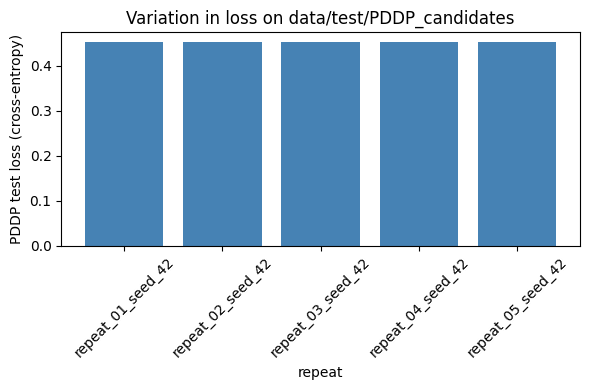

In [17]:
import importlib.util
import inspect
import tempfile
from pathlib import Path

import numpy as np
import torch
from torch_geometric.loader import DataLoader

if str(MINIMAL) not in sys.path:
    sys.path.insert(0, str(MINIMAL))

from gnn.checkpoint_meta import load_peptide_gnn_meta, resolve_node_layout_for_checkpoint
from gnn.data_utils import PeptideGraphDataset
from gnn.models import PeptideGNN, esm2_hidden_dim_from_state_dict, esm2_raw_dim_from_state_dict
from gnn.train import evaluate

_rg_path = MINIMAL / "scripts" / "run_gnn_train_final_models.py"
_rg_spec = importlib.util.spec_from_file_location("_rg_final", _rg_path)
_rg_mod = importlib.util.module_from_spec(_rg_spec)
assert _rg_spec.loader is not None
_rg_spec.loader.exec_module(_rg_mod)
create_feature_cols = _rg_mod.create_feature_cols
QSAR_COLS = [
    "netCharge",
    "FC",
    "LW",
    "DP",
    "NK",
    "AE",
    "pcMK",
    "_SolventAccessibilityD1025",
    "tau2_GRAR740104",
    "tau4_GRAR740104",
    "QSO50_GRAR740104",
    "QSO29_GRAR740104",
]

PDDP_ROOT = MINIMAL / "data" / "test" / "PDDP_candidates"
CANDIDATES_TXT = PDDP_ROOT / "candidates.txt"


def _resolve_pddp_workspace() -> dict[str, str]:
    from peptide_pipeline.manifest_paths import (
        gnn_final_training_paths_from_work_dir,
        resolve_generated_workspace,
    )

    gen = PDDP_ROOT / "generated"
    if gen.is_dir():
        try:
            ws = resolve_generated_workspace(gen)
            return gnn_final_training_paths_from_work_dir(ws)
        except (FileNotFoundError, KeyError, OSError):
            pass
    for name in ("geometric_features_clustered.csv", "geometric_features.csv"):
        p = PDDP_ROOT / name
        if p.is_file():
            esm_dir = p.parent / "esm2_per_residue"
            qsar = p.parent / "qsar12_descriptors.csv"
            return {
                "csv_path": str(p.resolve()),
                "pdb_dir": str((PDDP_ROOT / "structures").resolve()),
                "qsar_csv": str(qsar.resolve()) if qsar.is_file() else str(p.resolve()),
                "esm2_csv": str(p.parent / "esm2_embeddings.csv") if (p.parent / "esm2_embeddings.csv").is_file() else "",
                "esm2_residue_dir": str(esm_dir.resolve()) if esm_dir.is_dir() else "",
            }
    raise FileNotFoundError(
        f"No PDDP test workspace under {PDDP_ROOT}: add generated/ with pipeline_manifest.json "
        f"or place geometric_features(_clustered).csv + structures/ here."
    )


def _load_candidates() -> pd.DataFrame:
    rows = []
    for line in CANDIDATES_TXT.read_text(encoding="utf-8").splitlines():
        parts = line.split(None, 1)
        if len(parts) < 2:
            continue
        pid, _seq = parts[0], parts[1].strip()
        lab = 1 if pid.lower().startswith("high_") else 0
        rows.append({"peptide_id": pid, "label": lab})
    return pd.DataFrame(rows)


def _torch_load_ckpt(path: Path) -> dict:
    kw = {"map_location": "cpu"}
    try:
        sig = inspect.signature(torch.load)
        if "weights_only" in sig.parameters:
            kw["weights_only"] = True
    except (TypeError, ValueError, AttributeError):
        pass
    return torch.load(str(path), **kw)


def _build_pddp_test_csv(bundle: dict[str, str]) -> Path:
    cand = _load_candidates()
    geo = pd.read_csv(bundle["csv_path"])
    if "peptide_id" not in geo.columns:
        raise ValueError(f"PDDP geometric CSV missing peptide_id: {bundle['csv_path']}")
    geo = geo.drop(columns=["label"], errors="ignore")
    merged = cand.merge(geo, on="peptide_id", how="inner")
    merged["label"] = merged["label"].astype(int)
    if len(merged) < len(cand):
        miss = set(cand["peptide_id"]) - set(merged["peptide_id"])
        print(f"Warning: {len(miss)} candidate id(s) missing from geometric CSV (showing up to 8):", flush=True)
        for x in list(miss)[:8]:
            print(f"  {x}", flush=True)
    tmp = Path(tempfile.mkdtemp(prefix="pddp_test_")) / "pddp_subset.csv"
    merged.to_csv(tmp, index=False)
    return tmp


def _preset_feature_cols(preset: str) -> tuple[list[str], bool]:
    fs = (cfg_json.get("feature_sets") or {}).get(preset)
    if not fs:
        return [], False
    use_geo = bool(fs.get("use_geo"))
    use_qsar = bool(fs.get("use_qsar"))
    cols = create_feature_cols(use_geo, use_qsar, QSAR_COLS)
    return cols, bool(cols)


def pddp_test_loss_for_checkpoint(
    ckpt: Path,
    architecture: str,
    preset: str,
    *,
    test_csv: str,
    pdb_dir: str,
    esm2_residue_dir: str | None,
    distance_threshold: float,
    batch_size: int,
    device: torch.device,
) -> float:
    arch = str(architecture).lower().strip()
    feature_cols, use_geo = _preset_feature_cols(preset)
    scaler_path = None
    if use_geo:
        scaler_sidecar = ckpt.with_name(ckpt.stem + "_tabular_scaler.joblib")
        if scaler_sidecar.is_file():
            scaler_path = str(scaler_sidecar)

    sd = _torch_load_ckpt(ckpt)
    esm2_raw = esm2_raw_dim_from_state_dict(sd)
    esm2_h = esm2_hidden_dim_from_state_dict(sd)
    ng_infer, in_base_ckpt, _notes = resolve_node_layout_for_checkpoint(
        ckpt, sd, arch, user_node_groups=None
    )
    if esm2_raw > 0 and not (esm2_residue_dir and Path(esm2_residue_dir).is_dir()):
        raise FileNotFoundError(
            f"Checkpoint {ckpt.name} expects per-residue ESM2 but esm2_residue_dir is missing: {esm2_residue_dir!r}"
        )

    ds = PeptideGraphDataset(
        csv_path=test_csv,
        pdb_dir=pdb_dir,
        distance_threshold=float(distance_threshold),
        use_geometric_features=use_geo,
        geometric_feature_cols=feature_cols if use_geo else None,
        tabular_scaler_path=scaler_path,
        esm2_residue_dir=esm2_residue_dir if esm2_raw > 0 else None,
        node_feature_groups=ng_infer,
    )
    if len(ds) == 0:
        raise RuntimeError("PDDP test subset is empty after merge / filtering.")
    xw = int(ds[0].x.shape[1])
    if xw != in_base_ckpt:
        raise RuntimeError(f"Node width mismatch: dataset {xw} vs checkpoint {in_base_ckpt}")

    meta = load_peptide_gnn_meta(ckpt) or {}
    hidden = int(meta.get("hidden_channels", cfg_json.get("hidden_channels", 64)))
    n_layers = int(meta.get("num_layers", cfg_json.get("num_layers", 3)))
    dropout = float(meta.get("dropout", cfg_json.get("dropout", 0.2)))
    pooling = str(meta.get("pooling", "mean_max"))
    geo_dim = int(meta.get("geo_feature_dim", len(feature_cols)))

    model = PeptideGNN(
        architecture=arch,
        in_channels=in_base_ckpt,
        hidden_channels=hidden,
        num_layers=n_layers,
        dropout=dropout,
        num_classes=2,
        pooling=pooling,
        geo_feature_dim=geo_dim,
        esm2_raw_dim=esm2_raw,
        esm2_hidden_dim=esm2_h,
    )
    model.load_state_dict(sd)
    model = model.to(device)
    loader = DataLoader(list(ds), batch_size=batch_size, shuffle=False)
    metrics = evaluate(model, loader, device)
    return float(metrics["loss"])


def _pddp_row_matches_models(row: pd.Series) -> bool:
    specs = globals().get("MODELS")
    if not specs:
        return True
    arch = str(row.get("architecture", "")).lower().strip()
    pre = str(row.get("preset") or row.get("feature_set") or "").strip().lower()
    for s in specs:
        s = str(s).strip().lower()
        if ":" not in s:
            continue
        a, p = s.split(":", 1)
        if a.strip() == arch and p.strip() == pre:
            return True
    return False


try:
    _bundle = _resolve_pddp_workspace()
    _test_csv = _build_pddp_test_csv(_bundle)
    _esm_r = _bundle.get("esm2_residue_dir") or None
    if _esm_r == "":
        _esm_r = None
    _dist = float(cfg_json.get("distance_threshold", 8.0))
    _bs = int(cfg_json.get("batch_size", 32))
    _dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    _df_pddp = df[df.apply(_pddp_row_matches_models, axis=1)].copy()
    if _df_pddp.empty:
        raise RuntimeError(
            "PDDP: no rows left after MODELS filter; set MODELS=None or match architecture:preset in df."
        )
    pddp_losses: list[tuple[str, float]] = []
    for _, row in _df_pddp.iterrows():
        ck = Path(str(row["checkpoint"]))
        loss = pddp_test_loss_for_checkpoint(
            ck,
            str(row["architecture"]),
            str(row.get("preset") or row.get("feature_set") or "ESM"),
            test_csv=str(_test_csv),
            pdb_dir=_bundle["pdb_dir"],
            esm2_residue_dir=_esm_r,
            distance_threshold=_dist,
            batch_size=_bs,
            device=_dev,
        )
        pddp_losses.append((str(row["run_name"]), loss))

    pddp_df = pd.DataFrame(pddp_losses, columns=["run_name", "pddp_test_loss"])
    display(pddp_df)

    try:
        import matplotlib.pyplot as plt
    except ImportError:
        plt = None
    if plt is not None:
        fig, ax = plt.subplots(figsize=(max(6, 0.45 * len(pddp_df)), 4))
        ax.bar(pddp_df["run_name"].astype(str), pddp_df["pddp_test_loss"], color="steelblue")
        ax.set_ylabel("PDDP test loss (cross-entropy)")
        ax.set_xlabel("repeat")
        ax.tick_params(axis="x", rotation=45)
        ax.set_title("Variation in loss on data/test/PDDP_candidates")
        fig.tight_layout()
        plt.show()
except FileNotFoundError as e:
    print("PDDP test evaluation skipped:", e)
except Exception as e:
    raise RuntimeError(f"PDDP test evaluation failed: {e}") from e


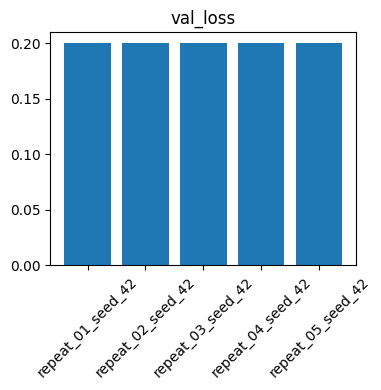

In [18]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

if plt is None or not metric_cols:
    print("Install matplotlib for plots, or inspect the table above.")
elif len(df) > df["run_name"].nunique():
    print("Multiple checkpoints per repeat; skip bar chart or pivot df by architecture/feature_set.")
else:
    fig, axes = plt.subplots(1, len(metric_cols), figsize=(4 * len(metric_cols), 4), squeeze=False)
    for ax, col in zip(axes[0], metric_cols):
        ax.bar(df["run_name"].astype(str), df[col])
        ax.set_title(col)
        ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    plt.show()